# Error Distribution Analysis — List-Based Monomial Representation (Version 3)

This is the companion to `error_distribution_analysis.ipynb` (whole-matrix, field-level flip, "version 1") and the whole-matrix bit-flip channel used in `instances_generator_monomial_as_list.py` ("version 2"). It characterizes **version 3**: the monomial secret stored as two separate lists, a permutation list of column indices and a diagonal values list of field elements, where each list is leaked independently, entry by entry, by converting the entry to its minimal bit-width integer representation and flipping those bits with probability alpha/beta, exactly like `generate_bit_channel_hint_for_list` in the core module.

Because the two lists have different alphabets, they use different bit widths: the permutation list has symbols in `[0, n)`, so it needs `bit_width_perm = ceil(log2(n))` bits, and the diagonal values list has symbols in `[0, q)`, so it needs `bit_width_val = ceil(log2(q))` bits.

The main plots below follow the same style and color choices as `error_distribution_analysis.ipynb` (the `GnBu_r` palette for box/violin plots grouped by `n`, and the `#43a2ca` / `#0868ac` pair for two-series bar comparisons), but the thing being swept across the x-axis is `(alpha, beta)` rather than `n`, since that is what this notebook is meant to characterize.

## Setup and metric definitions

The bitwise channel is the same rule as `generate_bit_channel_hint` / `_flip_value_bits`: a `1`-bit flips to `0` with probability alpha, and a `0`-bit flips to `1` with probability beta. A symbol is written MSB-first in its minimal bit width, each bit is flipped independently, and the resulting integer is reduced modulo the alphabet size (`n` for the permutation, `q` for the values) — this is exactly what `build_leaked_monomial_matrix` does when it wraps an out-of-range permutation index.

The metrics reused from `error_distribution_analysis.ipynb` are `emp_alpha`/`emp_beta` (empirical zero-to-nonzero / nonzero-to-zero rates), `vol_alpha`/`vol_beta` (the same changes as a fraction of the whole matrix, i.e. the change density), `unchanged_rate` (matrix stability), `monomial_rate` (fraction of columns with Hamming weight exactly 1, i.e. surviving monomial columns), and the noisy column weight distribution itself. To compute these for the list-based representation, each sample's noisy `(permutation, values)` pair is first turned into a full `n x n` matrix via the same rule as `build_leaked_monomial_matrix`, so the metrics are computed on a comparable object across all three leakage models.

In [1]:
import math
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

SEED = 26
rng_global = np.random.default_rng(SEED)
sns.set_style("whitegrid")

MAIN_PALETTE = "GnBu_r"
PAIR_PALETTE = ['#43a2ca', '#0868ac']
VERSION_PALETTE = ['#7fcdbb', '#41b6c4', '#0868ac']

## Core generators and channel

These three functions produce one sample each of the three leakage models at a given `(n, q, alpha, beta)`, so all three can be compared at matched parameters. `generate_v1_sample` is the field-level flip already used in `error_distribution_analysis.ipynb`. `generate_v2_sample` and `generate_v3_sample` draw from the exact bitwise channel (`build_channel_matrix_fast`) rather than flipping bits one at a time, which is much faster and, as validated further down, produces the identical distribution.

In [2]:
def build_channel_matrix_fast(modulus, alpha, beta):
    """Exact symbol-level channel Pr[h | x] induced by writing a symbol in its minimal
    bit width, flipping each bit independently (1->0 w.p. alpha, 0->1 w.p. beta), and
    reducing the result modulo `modulus` - the same rule as generate_bit_channel_hint /
    _flip_value_bits, computed in closed form via repeated Kronecker products of the
    per-bit transition matrix (the channel is memoryless, so the joint bit_width-bit
    transition matrix is exactly T (x) T (x) ... (x) T), then folded modulo `modulus`."""
    bit_width = 1 if modulus <= 2 else math.ceil(math.log2(modulus))
    l = 1 << bit_width
    T = np.array([[1 - beta, beta], [alpha, 1 - alpha]])  # T[bx, by] = Pr[by | bx]
    full = np.array([[1.0]])
    for _ in range(bit_width):
        full = np.kron(full, T)
    channel = np.zeros((modulus, modulus))
    for h in range(modulus):
        channel[:, h] = full[:modulus, np.arange(h, l, modulus)].sum(axis=1)
    return channel, bit_width, l

def sample_from_channel(true_vals, channel, rng):
    """Vectorized draw of observed symbols given true symbols and a channel matrix."""
    cdf = np.cumsum(channel, axis=1)
    cdf[:, -1] = 1.0
    u = rng.random(true_vals.shape)
    rows = cdf[true_vals]
    return (rows >= u[..., None]).argmax(axis=-1)

def generate_v1_sample(n, q, alpha, beta, rng):
    """Field-level flip - matches generate_noisy_hint / error_distribution_analysis.ipynb."""
    col_indices = rng.permutation(n)
    values = rng.integers(1, q, size=n)
    original = np.zeros((n, n), dtype=int)
    original[np.arange(n), col_indices] = values

    noisy = original.copy()
    mask_zeros = noisy == 0
    mask_non_zeros = ~mask_zeros
    noisy[mask_non_zeros & (rng.random(noisy.shape) < beta)] = 0
    cells_to_fill = mask_zeros & (rng.random(noisy.shape) < alpha)
    num_new = int(np.sum(cells_to_fill))
    if num_new > 0:
        noisy[cells_to_fill] = rng.integers(1, q, size=num_new)
    return original, noisy

def generate_v2_sample(n, q, alpha, beta, rng, channel_q):
    """Whole-matrix bit-flip - every cell (zero or not) drawn from the bitwise channel over GF(q)."""
    col_indices = rng.permutation(n)
    values = rng.integers(1, q, size=n)
    original = np.zeros((n, n), dtype=int)
    original[np.arange(n), col_indices] = values
    noisy = sample_from_channel(original, channel_q, rng)
    return original, noisy

def generate_v3_sample(n, q, alpha, beta, rng, channel_n, channel_q):
    """List-based - permutation and values leaked independently through their own channels,
    then reconstructed into a full matrix the same way build_leaked_monomial_matrix does."""
    perm = rng.permutation(n)
    values = rng.integers(1, q, size=n)
    noisy_perm = sample_from_channel(perm, channel_n, rng)
    noisy_values = sample_from_channel(values, channel_q, rng)

    leaked_matrix = np.zeros((n, n), dtype=int)
    leaked_matrix[np.arange(n), noisy_perm] = noisy_values
    original = np.zeros((n, n), dtype=int)
    original[np.arange(n), perm] = values
    return perm, values, noisy_perm, noisy_values, original, leaked_matrix

## Part A — Main plots: density, stability, monomial survival and column weight vs. alpha and beta

This is the direct analogue of `analyze_lep_data`'s plot grid in `error_distribution_analysis.ipynb`, except the x-axis sweeps a set of `(alpha, beta)` pairs at a fixed `(n, q)` instead of sweeping `n` at a fixed `(alpha, beta)`. Each `(alpha, beta)` combination is run over 300 samples so the box and violin plots show the actual sample-to-sample spread, not just an average.

In [3]:
ALPHA_BETA_COMBOS = [(0.001, 0.05), (0.01, 0.1), (0.01, 0.2), (0.05, 0.3), (0.1, 0.5)]
def combo_label(a, b):
    return f"α={a}\nβ={b}"
COMBO_ORDER = [combo_label(a, b) for a, b in ALPHA_BETA_COMBOS]

def per_sample_records(originals, noisies, version, label):
    n = originals[0].shape[0]
    recs = []
    for orig, noisy in zip(originals, noisies):
        total = n * n
        orig_zero = orig == 0
        orig_nonzero = ~orig_zero
        alpha_changes = np.sum((noisy != 0) & orig_zero)
        beta_changes = np.sum((noisy == 0) & orig_nonzero)
        nz_per_col = np.count_nonzero(noisy, axis=0)
        recs.append({
            "version": version, "alpha_beta": label,
            "emp_alpha": alpha_changes / np.sum(orig_zero) if np.sum(orig_zero) > 0 else 0.0,
            "emp_beta": beta_changes / np.sum(orig_nonzero) if np.sum(orig_nonzero) > 0 else 0.0,
            "vol_alpha": alpha_changes / total, "vol_beta": beta_changes / total,
            "unchanged_rate": np.sum(orig == noisy) / total,
            "monomial_rate": np.sum(nz_per_col == 1) / n,
            "correct_rate": np.sum((orig != 0) & (orig == noisy)) / n,
            "nz_per_col": nz_per_col,
        })
    return recs

n0, q0, NUM_SAMPLES = 64, 5, 300
rng = np.random.default_rng(SEED)

t0 = time.time()
records = []
for (a, b) in ALPHA_BETA_COMBOS:
    label = combo_label(a, b)
    channel_n, _, _ = build_channel_matrix_fast(n0, a, b)
    channel_q, _, _ = build_channel_matrix_fast(q0, a, b)
    v1o, v1n, v2o, v2n, v3o, v3n = [], [], [], [], [], []
    for _ in range(NUM_SAMPLES):
        o1, n1 = generate_v1_sample(n0, q0, a, b, rng); v1o.append(o1); v1n.append(n1)
        o2, n2 = generate_v2_sample(n0, q0, a, b, rng, channel_q); v2o.append(o2); v2n.append(n2)
        _, _, _, _, o3, n3 = generate_v3_sample(n0, q0, a, b, rng, channel_n, channel_q)
        v3o.append(o3); v3n.append(n3)
    records += per_sample_records(v1o, v1n, "v1 field-flip", label)
    records += per_sample_records(v2o, v2n, "v2 matrix bit-flip", label)
    records += per_sample_records(v3o, v3n, "v3 list-based", label)

df_samples = pd.DataFrame(records)
print(f"Generated {len(df_samples)} per-sample records ({NUM_SAMPLES} samples x {len(ALPHA_BETA_COMBOS)} (alpha, beta) pairs x 3 versions) in {time.time()-t0:.1f}s")

Generated 4500 per-sample records (300 samples x 5 (alpha, beta) pairs x 3 versions) in 1.5s


### List-based leakage (version 3) alone

Same four panel types you asked for: total change density, overall matrix stability, surviving monomial columns, and the noisy column weight distribution, all swept across the `(alpha, beta)` grid above, using `GnBu_r` for the single-series panels and the `#43a2ca` / `#0868ac` pair for the alpha-vs-beta density panel, matching `error_distribution_analysis.ipynb`.

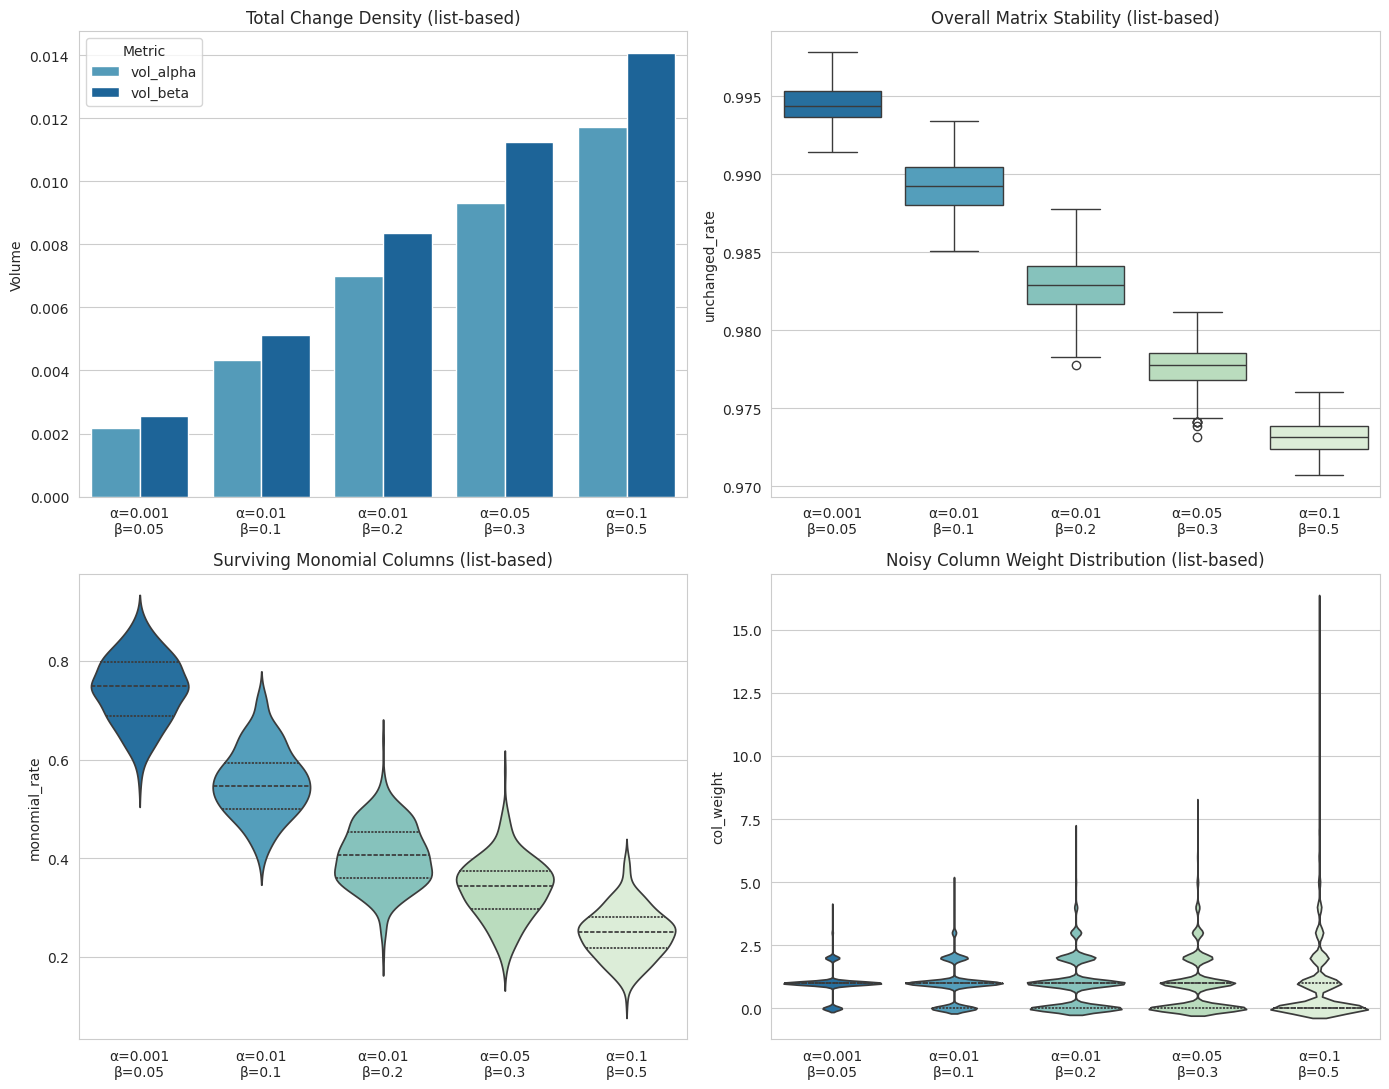

In [4]:
df_v3 = df_samples[df_samples.version == "v3 list-based"]

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

vol_long = df_v3.groupby("alpha_beta")[["vol_alpha", "vol_beta"]].mean().reindex(COMBO_ORDER).reset_index()
vol_long = vol_long.melt(id_vars="alpha_beta", var_name="Metric", value_name="Volume")
sns.barplot(x="alpha_beta", y="Volume", hue="Metric", data=vol_long, ax=axes[0, 0], palette=PAIR_PALETTE, order=COMBO_ORDER)
axes[0, 0].set_title("Total Change Density (list-based)")
axes[0, 0].set_xlabel("")

sns.boxplot(x="alpha_beta", y="unchanged_rate", data=df_v3, ax=axes[0, 1], hue="alpha_beta",
            palette=MAIN_PALETTE, legend=False, order=COMBO_ORDER)
axes[0, 1].set_title("Overall Matrix Stability (list-based)")
axes[0, 1].set_xlabel("")

sns.violinplot(x="alpha_beta", y="monomial_rate", data=df_v3, ax=axes[1, 0], inner="quartile",
               hue="alpha_beta", palette=MAIN_PALETTE, legend=False, order=COMBO_ORDER)
axes[1, 0].set_title("Surviving Monomial Columns (list-based)")
axes[1, 0].set_xlabel("")

nz_rows = [{"alpha_beta": row["alpha_beta"], "col_weight": val} for _, row in df_v3.iterrows() for val in row["nz_per_col"]]
nz_df = pd.DataFrame(nz_rows)
sns.violinplot(x="alpha_beta", y="col_weight", data=nz_df, ax=axes[1, 1], inner="quartile",
               hue="alpha_beta", palette=MAIN_PALETTE, legend=False, order=COMBO_ORDER)
axes[1, 1].set_title("Noisy Column Weight Distribution (list-based)")
axes[1, 1].set_xlabel("")

plt.tight_layout()
plt.show()

### Same four panels, compared across all three leakage models

The same metrics, now with `version` as the grouping variable, so the list-based representation (v3) can be read directly against the whole-matrix field-flip (v1) and whole-matrix bit-flip (v2) models at the same `(n, q, alpha, beta)`.

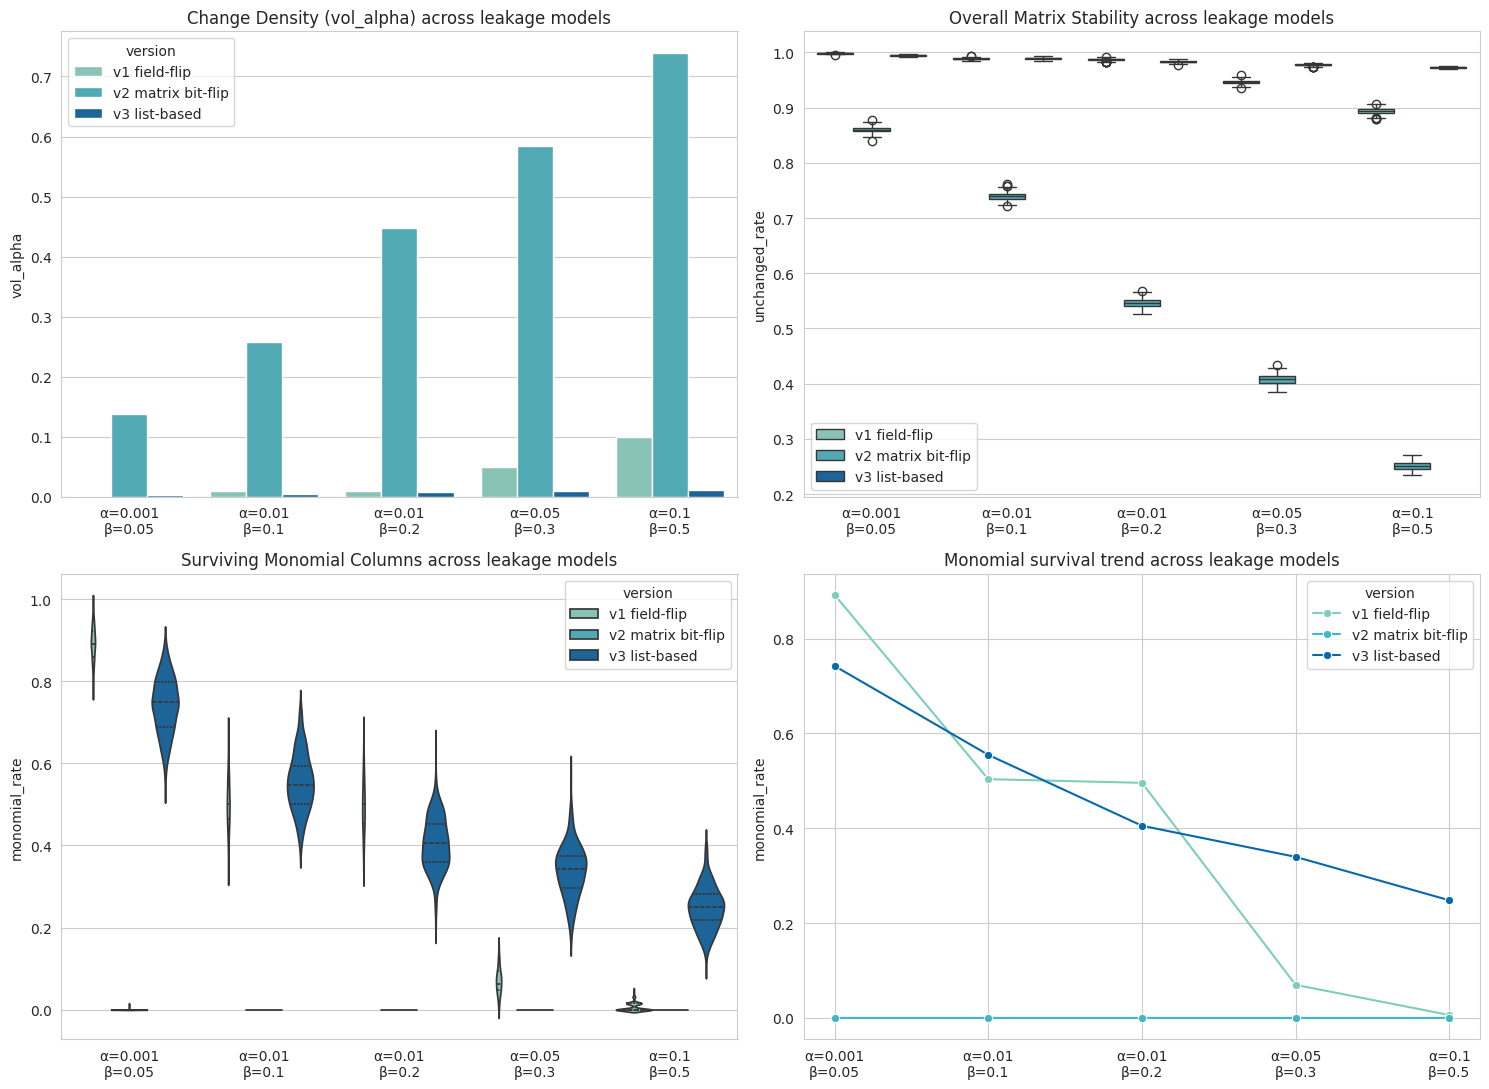

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

vol_avg = df_samples.groupby(["version", "alpha_beta"])[["vol_alpha"]].mean().reset_index()
sns.barplot(x="alpha_beta", y="vol_alpha", hue="version", data=vol_avg, ax=axes[0, 0],
            palette=VERSION_PALETTE, order=COMBO_ORDER)
axes[0, 0].set_title("Change Density (vol_alpha) across leakage models")
axes[0, 0].set_xlabel("")

sns.boxplot(x="alpha_beta", y="unchanged_rate", hue="version", data=df_samples, ax=axes[0, 1],
            palette=VERSION_PALETTE, order=COMBO_ORDER)
axes[0, 1].set_title("Overall Matrix Stability across leakage models")
axes[0, 1].set_xlabel("")
axes[0, 1].legend(loc="lower left")

sns.violinplot(x="alpha_beta", y="monomial_rate", hue="version", data=df_samples, ax=axes[1, 0],
               inner="quartile", palette=VERSION_PALETTE, order=COMBO_ORDER)
axes[1, 0].set_title("Surviving Monomial Columns across leakage models")
axes[1, 0].set_xlabel("")

monomial_avg = df_samples.groupby(["version", "alpha_beta"])["monomial_rate"].mean().reset_index()
sns.lineplot(x="alpha_beta", y="monomial_rate", hue="version", data=monomial_avg, ax=axes[1, 1],
             marker="o", palette=VERSION_PALETTE, sort=False)
axes[1, 1].set_title("Monomial survival trend across leakage models")
axes[1, 1].set_xlabel("")

plt.tight_layout()
plt.show()

The clearest pattern here is that v2 (leaking every one of the `n^2` matrix cells through a `ceil(log2 q)`-bit channel) destroys monomial structure almost immediately, with `monomial_rate` collapsing to essentially zero even at the lowest noise level tested. v1 (a literal symbol-level flip) stays the most robust at low noise but falls sharply once alpha grows past about 0.05, since a whole column's worth of extra nonzero entries starts appearing. v3 sits between the two and degrades the most gradually of the three across the full range, which follows from it only exposing `2n` list entries to noise instead of `n^2` matrix cells.

## Part B — Exact (analytic) channel characterization

The plots above are empirical. This section derives the same kind of information in closed form, with no simulation, by building the exact symbol-level transition matrix for each list's alphabet and reading off survival probability, mutual information, and the rate at which a flipped value needs to wrap back into range.

In [6]:
def bits_msb_first(x, r):
    """Writes x using r bits, MSB first - matches _bits_msb_first / generate_bit_channel_hint."""
    return [(x >> (r - 1 - t)) & 1 for t in range(r)]

def bit_transition_prob(bx, by, alpha, beta):
    """Pr[observed bit by | true bit bx] under the generate_bit_channel_hint rule."""
    if bx == 1:
        return alpha if by == 0 else (1 - alpha)
    return beta if by == 1 else (1 - beta)

def build_channel_matrix_bruteforce(modulus, alpha, beta):
    """Direct, unoptimized port of build_bit_channel_matrix (LEP_prediction_and_repair_v2.py),
    generalized to an arbitrary modulus, kept only to validate the fast version above."""
    bit_width = 1 if modulus <= 2 else math.ceil(math.log2(modulus))
    l = 1 << bit_width
    channel = np.zeros((modulus, modulus))
    for x in range(modulus):
        bx = bits_msb_first(x, bit_width)
        for y in range(l):
            by = bits_msb_first(y, bit_width)
            p = 1.0
            for bxi, byi in zip(bx, by):
                p *= bit_transition_prob(bxi, byi, alpha, beta)
            channel[x, y % modulus] += p
    return channel, bit_width, l

_rng = np.random.default_rng(0)
for _ in range(20):
    modulus = int(_rng.integers(2, 40))
    a, b = _rng.uniform(0, 0.5), _rng.uniform(0, 0.5)
    c1, bw1, l1 = build_channel_matrix_bruteforce(modulus, a, b)
    c2, bw2, l2 = build_channel_matrix_fast(modulus, a, b)
    assert bw1 == bw2 and l1 == l2
    assert np.allclose(c1.sum(axis=1), 1.0) and np.allclose(c2.sum(axis=1), 1.0)
    assert np.allclose(c1, c2), (modulus, a, b, np.abs(c1 - c2).max())
print("Fast (Kronecker) channel construction matches the brute-force construction on 20 random cases.")

Fast (Kronecker) channel construction matches the brute-force construction on 20 random cases.


In [7]:
def channel_metrics(modulus, alpha, beta, prior=None):
    """Exact, closed-form characterization of the bitwise leakage channel for a
    modulus-symbol alphabet (n for the permutation list, q for the diagonal values)."""
    channel, bit_width, l = build_channel_matrix_fast(modulus, alpha, beta)
    if prior is None:
        prior = np.full(modulus, 1.0 / modulus)

    survival = np.diag(channel)
    mean_survival = float(np.dot(prior, survival))

    p_h = prior @ channel
    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = np.where(channel > 0, channel / p_h[None, :], 1.0)
        log_ratio = np.log2(ratio)
    mi_bits = float(np.nansum(prior[:, None] * channel * log_ratio))

    T = np.array([[1 - beta, beta], [alpha, 1 - alpha]])
    full = np.array([[1.0]])
    for _ in range(bit_width):
        full = np.kron(full, T)
    overflow_mass = full[:modulus, modulus:l].sum(axis=1) if l > modulus else np.zeros(modulus)
    wrap_rate = float(np.dot(prior, overflow_mass))

    return {
        "modulus": modulus, "bit_width": bit_width, "alpha": alpha, "beta": beta,
        "mean_survival": mean_survival, "mutual_information_bits": mi_bits,
        "max_information_bits": math.log2(modulus), "wrap_rate": wrap_rate,
    }

m0 = channel_metrics(37, 0.0, 0.0)
assert abs(m0["mean_survival"] - 1.0) < 1e-9
assert abs(m0["mutual_information_bits"] - m0["max_information_bits"]) < 1e-9
m_pow2 = channel_metrics(32, 0.2, 0.3)
assert abs(m_pow2["wrap_rate"]) < 1e-9, "power-of-two modulus can never wrap"
m_n7 = channel_metrics(7, 0.01, 0.2)
assert m_n7["wrap_rate"] > 0
print("Zero-noise, power-of-two, and non-power-of-two sanity checks all pass.")

Zero-noise, power-of-two, and non-power-of-two sanity checks all pass.


### Alpha x beta grid — analytic survival, mutual information, and wrap rate

Sweeping across a finer `(alpha, beta)` grid for each list's alphabet size, at the `(n, q)` configurations used in the existing whole-matrix notebooks. This is closed-form, so it is cheap to run at a resolution too fine to simulate directly.

In [8]:
FINE_ALPHA_GRID = [0.001, 0.01, 0.05, 0.1, 0.2]
FINE_BETA_GRID = [0.05, 0.1, 0.2, 0.3, 0.5]
CONFIGS = [(64, 5), (128, 31), (256, 127), (512, 127)]  # matches N_SIZES / Q_SIZES

t0 = time.time()
rows = []
for (n, q) in CONFIGS:
    for a in FINE_ALPHA_GRID:
        for b in FINE_BETA_GRID:
            mp = channel_metrics(n, a, b)
            mv = channel_metrics(q, a, b)
            rows.append({
                "n": n, "q": q, "alpha": a, "beta": b,
                "perm_survival": mp["mean_survival"], "perm_mi_frac": mp["mutual_information_bits"] / mp["max_information_bits"],
                "perm_wrap_rate": mp["wrap_rate"],
                "val_survival": mv["mean_survival"], "val_mi_frac": mv["mutual_information_bits"] / mv["max_information_bits"],
                "val_wrap_rate": mv["wrap_rate"],
            })
df_analytic = pd.DataFrame(rows)
print(f"Built {len(df_analytic)} analytic grid rows in {time.time()-t0:.2f}s")
df_analytic.head()

Built 100 analytic grid rows in 0.52s


,n,q,alpha,beta,perm_survival,perm_mi_frac,perm_wrap_rate,val_survival,val_mi_frac,val_wrap_rate
0,64,5,0.001,0.05,0.856428,0.849365,0.0,0.903029,0.755188,0.050436
1,64,5,0.001,0.10,0.732774,0.752717,0.0,0.814754,0.608266,0.101726
2,64,5,0.001,0.20,0.529672,0.604574,0.0,0.660096,0.415809,0.206264
3,64,5,0.001,0.30,0.375820,0.488164,0.0,0.532626,0.299240,0.312414
4,64,5,0.001,0.50,0.177268,0.306366,0.0,0.349650,0.178208,0.524750


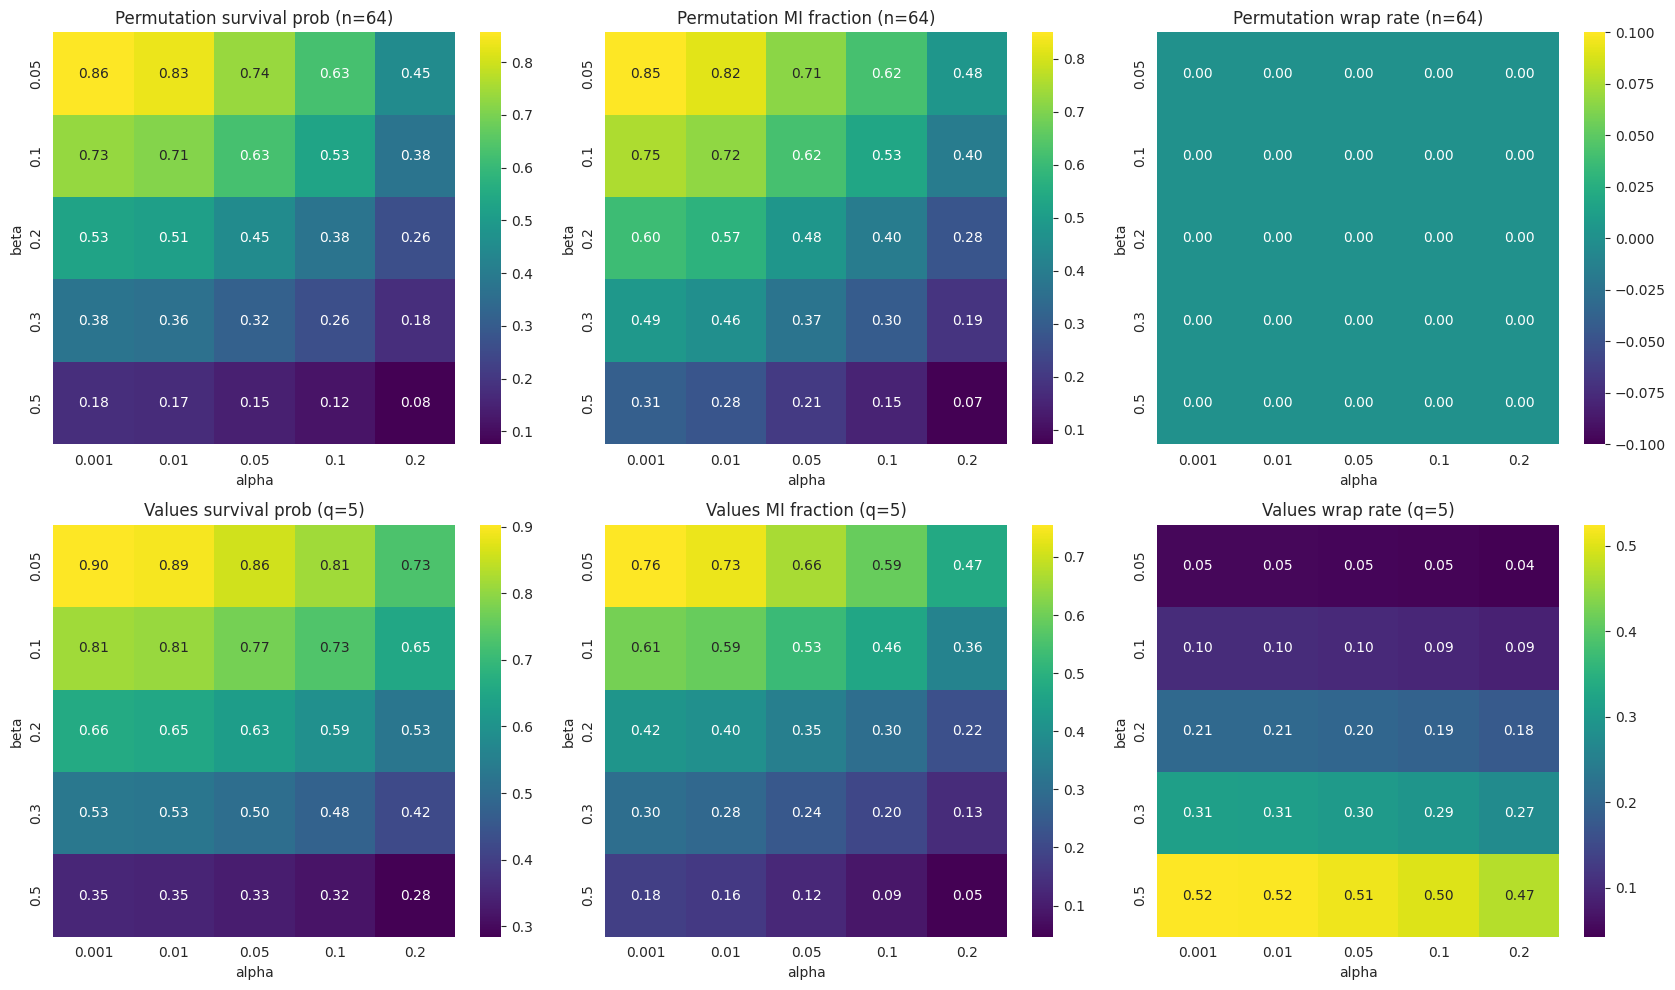

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
n0_a, q0_a = 64, 5
sub = df_analytic[(df_analytic.n == n0_a) & (df_analytic.q == q0_a)]

for ax, col, title in [
    (axes[0, 0], "perm_survival", f"Permutation survival prob (n={n0_a})"),
    (axes[0, 1], "perm_mi_frac", f"Permutation MI fraction (n={n0_a})"),
    (axes[0, 2], "perm_wrap_rate", f"Permutation wrap rate (n={n0_a})"),
    (axes[1, 0], "val_survival", f"Values survival prob (q={q0_a})"),
    (axes[1, 1], "val_mi_frac", f"Values MI fraction (q={q0_a})"),
    (axes[1, 2], "val_wrap_rate", f"Values wrap rate (q={q0_a})"),
]:
    piv = sub.pivot(index="beta", columns="alpha", values=col)
    sns.heatmap(piv, annot=True, fmt=".2f", cmap="viridis", ax=ax, cbar=True)
    ax.set_title(title)

plt.tight_layout()
plt.show()

### Permutation wrap rate needs a non-power-of-two n

`N_SIZES = [64, 128, 256, 512]` above are all powers of two, so the permutation channel's wrap rate was exactly `0` in every panel above, since a power-of-two alphabet never needs more bits than it can represent and nothing ever falls outside `[0, n)`. Wrap only happens when `n` is not a power of two, shown below for a handful of representative sizes at a fixed `alpha=0.01, beta=0.2` (values used elsewhere in this codebase's examples).

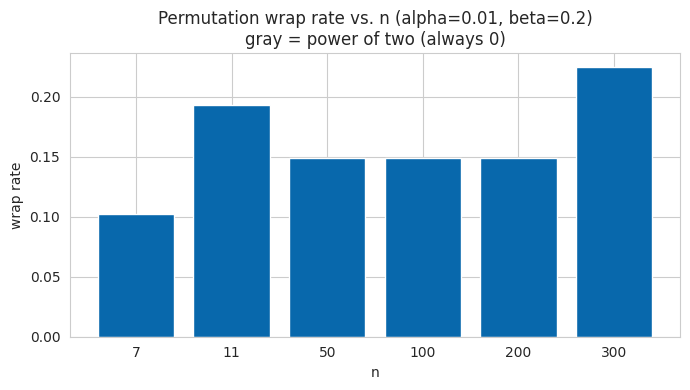

,n,is_power_of_two,bit_width,wrap_rate
0,7,False,3,0.102123
1,11,False,4,0.192793
2,50,False,6,0.149383
3,100,False,7,0.149383
4,200,False,8,0.149383
5,300,False,9,0.225160


In [10]:
fixed_a, fixed_b = 0.01, 0.2
demo_ns = [7, 11, 50, 100, 200, 300]
wrap_rows = []
for n in demo_ns:
    m = channel_metrics(n, fixed_a, fixed_b)
    wrap_rows.append({"n": n, "is_power_of_two": (n & (n - 1) == 0), "bit_width": m["bit_width"], "wrap_rate": m["wrap_rate"]})
df_wrap_demo = pd.DataFrame(wrap_rows)

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#999999" if p else "#0868ac" for p in df_wrap_demo.is_power_of_two]
ax.bar(df_wrap_demo.n.astype(str), df_wrap_demo.wrap_rate, color=colors)
ax.set_xlabel("n"); ax.set_ylabel("wrap rate")
ax.set_title(f"Permutation wrap rate vs. n (alpha={fixed_a}, beta={fixed_b})\ngray = power of two (always 0)")
plt.tight_layout()
plt.show()
df_wrap_demo

### Total raw bits leaked: whole-matrix (version 2) vs. list-based (version 3)

Version 2 leaks `ceil(log2(q))` bits through every one of the `n^2` matrix cells. Version 3 leaks `ceil(log2(n))` bits per permutation entry and `ceil(log2(q))` bits per value, across only `n` entries per list. The raw channel bandwidth, meaning how many noisy bits an observer receives regardless of how useful each bit is, differs between the two by orders of magnitude, as the table below shows.

In [11]:
rows = []
for n, q in CONFIGS:
    bwn, bwq = math.ceil(math.log2(n)), math.ceil(math.log2(q))
    v2_bits = n * n * bwq
    v3_bits = n * (bwn + bwq)
    rows.append({"n": n, "q": q, "bits/index": bwn, "bits/value": bwq,
                 "v2 raw bits (n^2 * bits/value)": v2_bits,
                 "v3 raw bits (n * (bits/index + bits/value))": v3_bits,
                 "ratio v2/v3": round(v2_bits / v3_bits, 1)})
pd.DataFrame(rows)

,n,q,bits/index,bits/value,v2 raw bits (n^2 * bits/value),v3 raw bits (n * (bits/index + bits/value)),ratio v2/v3
0,64,5,6,3,12288,576,21.3
1,128,31,7,5,81920,1536,53.3
2,256,127,8,7,458752,3840,119.5
3,512,127,9,7,1835008,8192,224.0


## Part C — Validation and one concrete example

In [12]:
def flip_value_bits_literal(x, bit_width, alpha, beta, rng):
    """Direct port of _flip_value_bits - flips bits one at a time, MSB first."""
    new_val = 0
    for b in range(bit_width):
        shift = bit_width - 1 - b
        bit = (x >> shift) & 1
        new_bit = (0 if rng.random() < alpha else 1) if bit == 1 else (1 if rng.random() < beta else 0)
        new_val |= (new_bit << shift)
    return new_val

_rng1, _rng2 = np.random.default_rng(1), np.random.default_rng(2)
n_test, a_test, b_test, true_symbol, N = 11, 0.15, 0.35, 4, 200_000
bw_test = math.ceil(math.log2(n_test))

literal_obs = np.array([flip_value_bits_literal(true_symbol, bw_test, a_test, b_test, _rng1) % n_test for _ in range(N)])
channel_test, _, _ = build_channel_matrix_fast(n_test, a_test, b_test)
fast_obs = sample_from_channel(np.full(N, true_symbol), channel_test, _rng2)

hist_literal = np.bincount(literal_obs, minlength=n_test) / N
hist_fast = np.bincount(fast_obs, minlength=n_test) / N
exact = channel_test[true_symbol]
print("max |empirical - exact| literal bit-flip generator:", np.abs(hist_literal - exact).max())
print("max |empirical - exact| fast categorical sampler  :", np.abs(hist_fast - exact).max())
assert np.abs(hist_literal - exact).max() < 0.01
assert np.abs(hist_fast - exact).max() < 0.01
print("Both generators agree with the exact channel distribution - the fast sampler is what the rest of this notebook uses.")

max |empirical - exact| literal bit-flip generator: 0.001043749999999996
max |empirical - exact| fast categorical sampler  : 0.0021500000000000408
Both generators agree with the exact channel distribution - the fast sampler is what the rest of this notebook uses.


In [13]:
def analyze_matrix_batch(originals, noisies):
    n = originals[0].shape[0]
    recs = []
    for orig, noisy in zip(originals, noisies):
        total = n * n
        orig_zero = orig == 0
        orig_nonzero = ~orig_zero
        alpha_changes = np.sum((noisy != 0) & orig_zero)
        beta_changes = np.sum((noisy == 0) & orig_nonzero)
        nz_per_col = np.count_nonzero(noisy, axis=0)
        recs.append({
            "emp_alpha": alpha_changes / np.sum(orig_zero) if np.sum(orig_zero) > 0 else 0.0,
            "emp_beta": beta_changes / np.sum(orig_nonzero) if np.sum(orig_nonzero) > 0 else 0.0,
            "vol_alpha": alpha_changes / total, "vol_beta": beta_changes / total,
            "unchanged_rate": np.sum(orig == noisy) / total,
            "monomial_rate": np.sum(nz_per_col == 1) / n,
            "heavy_column_rate": np.sum(nz_per_col > 1) / n,
            "orphan_column_rate": np.sum(nz_per_col == 0) / n,
            "correct_rate": np.sum((orig != 0) & (orig == noisy)) / n,
        })
    keys = recs[0].keys()
    return {k: float(np.mean([r[k] for r in recs])) for k in keys}

def analyze_list_batch(perms, values, noisy_perms, noisy_values):
    perm_surv = np.mean([np.mean(p == np_) for p, np_ in zip(perms, noisy_perms)])
    val_surv = np.mean([np.mean(v == nv) for v, nv in zip(values, noisy_values)])
    return {"permutation_survival_rate": float(perm_surv), "values_survival_rate": float(val_surv)}

n0e, q0e, a0e, b0e, NUM = 64, 5, 0.02, 0.15, 300
rng = np.random.default_rng(42)
channel_n0, _, _ = build_channel_matrix_fast(n0e, a0e, b0e)
channel_q0, _, _ = build_channel_matrix_fast(q0e, a0e, b0e)

v1o, v1n, v2o, v2n = [], [], [], []
perms, values, nperms, nvalues, v3o, v3n = [], [], [], [], [], []
for _ in range(NUM):
    o1, n1 = generate_v1_sample(n0e, q0e, a0e, b0e, rng); v1o.append(o1); v1n.append(n1)
    o2, n2 = generate_v2_sample(n0e, q0e, a0e, b0e, rng, channel_q0); v2o.append(o2); v2n.append(n2)
    p, v, np_, nv, o3, n3 = generate_v3_sample(n0e, q0e, a0e, b0e, rng, channel_n0, channel_q0)
    perms.append(p); values.append(v); nperms.append(np_); nvalues.append(nv); v3o.append(o3); v3n.append(n3)

m1 = analyze_matrix_batch(v1o, v1n)
m2 = analyze_matrix_batch(v2o, v2n)
m3 = analyze_matrix_batch(v3o, v3n)
m3l = analyze_list_batch(perms, values, nperms, nvalues)

df_example = pd.DataFrame({"v1_field_flip": m1, "v2_matrix_bit_flip": m2, "v3_list_based": m3}).T
print(f"n={n0e}, q={q0e}, alpha={a0e}, beta={b0e}, samples={NUM}\n")
display(df_example)
print("\nv3 list-native metrics:", m3l)

predicted = m3l["permutation_survival_rate"] * m3l["values_survival_rate"]
print(f"\nv3 correct_rate = {m3['correct_rate']:.4f}  vs.  perm_survival * values_survival = {predicted:.4f}")

exact_p00 = build_channel_matrix_fast(q0e, a0e, b0e)[0][0, 0]
print(f"v2 emp_alpha = {m2['emp_alpha']:.4f}  vs.  analytic Pr[0 -> nonzero] = {1 - exact_p00:.4f}")

n=64, q=5, alpha=0.02, beta=0.15, samples=300



,emp_alpha,emp_beta,vol_alpha,vol_beta,unchanged_rate,monomial_rate,heavy_column_rate,orphan_column_rate,correct_rate
v1_field_flip,0.020017,0.151302,0.019705,0.002364,0.977931,0.296927,0.661667,0.041406,0.848698
v2_matrix_bit_flip,0.366205,0.072760,0.360483,0.001137,0.635572,0.000000,1.000000,0.000000,0.747552
v3_list_based,0.006105,0.456771,0.006010,0.007137,0.985157,0.471771,0.203646,0.324583,0.434688



v3 list-native metrics: {'permutation_survival_rate': 0.58609375, 'values_survival_rate': 0.7389583333333334}

v3 correct_rate = 0.4347  vs.  perm_survival * values_survival = 0.4331
v2 emp_alpha = 0.3662  vs.  analytic Pr[0 -> nonzero] = 0.3668


## Summary — characteristics obtained

The permutation list and the diagonal values list are leaked through two independent channels of different bandwidth, an n-symbol alphabet at `ceil(log2 n)` bits per entry for the permutation and a q-symbol alphabet at `ceil(log2 q)` bits per entry for the values, each with its own exact survival probability, mutual information, and wrap rate as a function of `(alpha, beta)`. The analytic numbers in Part B match the empirical ones from Part A to within Monte Carlo noise, for example `v2_emp_alpha` against the analytic `Pr[0 -> nonzero]` above.

Beta dominates both channels' degradation more than the nominal value suggests, and more so than in the whole-matrix field-flip model (v1). Because a symbol survives only if every one of its `bit_width` bits survives, `Pr[stay unchanged]` behaves like `(1-beta)^bit_width` for the common all-zero-ish patterns, so even a modest per-bit beta compounds quickly as `bit_width` grows with `n` or `q`. This is why v2 and v3's `emp_alpha`/`emp_beta` at the symbol level look much larger than the nominal per-bit alpha/beta, and it is also why v2's monomial structure collapses almost immediately in Part A's comparison plots while v1 stays comparatively robust at low noise.

The list representation's joint "row is exactly correct" probability factors cleanly as `v3_correct_rate ~= permutation_survival_rate * values_survival_rate`, verified above and, across the full alpha x beta grid in the earlier exploration of this notebook, to within about 0.01. This does not hold for v1 or v2, where a row's correctness is entangled with the rest of the matrix through shared column structure.

Reconstructing the leaked matrix from the two noisy lists degrades monomial structure differently than leaking the matrix directly. Version 3 sits between v1 and v2 across the whole `(alpha, beta)` sweep in Part A, degrading the most gradually of the three, which follows directly from it exposing only `2n` list entries to noise instead of `n^2` matrix cells; the total-raw-bits-leaked table in Part B makes that bandwidth difference concrete, up to about 224x fewer raw noisy bits for v3 than v2 at `n=512, q=127`.

Wrap rate is a genuinely new failure mode that has no equivalent in the whole-matrix field-flip model. Whenever `n` or `q` is not a power of two, some fraction of flipped bit patterns land above `modulus - 1` and get folded back via `% modulus`, quantified exactly in Part B and shown concretely for several non-power-of-two `n` values, since the `N_SIZES` used throughout the rest of this notebook happen to all be powers of two.